In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
df = pd.read_csv('../data/raw/food_waste.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (214, 12)

First 5 rows:


,Country,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),Confidence in estimate,M49 code,Region,Source
0,Afghanistan,126,82,3109153,16,594982,28,1051783,Very Low Confidence,4,Southern Asia,https://www.unep.org/resources/report/unep-foo...
1,Albania,127,83,238492,16,45058,28,79651,Very Low Confidence,8,Southern Europe,https://www.unep.org/resources/report/unep-foo...
2,Algeria,135,91,3918529,16,673360,28,1190335,Very Low Confidence,12,Northern Africa,https://www.unep.org/resources/report/unep-foo...
3,Andorra,123,84,6497,13,988,26,1971,Low Confidence,20,Southern Europe,https://www.unep.org/resources/report/unep-foo...
4,Angola,144,100,3169523,16,497755,28,879908,Very Low Confidence,24,Sub-Saharan Africa,https://www.unep.org/resources/report/unep-foo...


In [4]:
print("=== DATASET INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== BASIC STATISTICS ===")
df.describe()

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   Country                                 214 non-null    str  
 1   combined figures (kg/capita/year)       214 non-null    int64
 2   Household estimate (kg/capita/year)     214 non-null    int64
 3   Household estimate (tonnes/year)        214 non-null    int64
 4   Retail estimate (kg/capita/year)        214 non-null    int64
 5   Retail estimate (tonnes/year)           214 non-null    int64
 6   Food service estimate (kg/capita/year)  214 non-null    int64
 7   Food service estimate (tonnes/year)     214 non-null    int64
 8   Confidence in estimate                  214 non-null    str  
 9   M49 code                                214 non-null    int64
 10  Region                                  214 non-null    str  
 11  Source   

,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),M49 code
count,214.000000,214.000000,2.140000e+02,214.000000,2.140000e+02,214.000000,2.140000e+02,214.000000
mean,126.794393,84.294393,2.658896e+06,15.116822,5.520454e+05,27.383178,1.138859e+06,433.971963
std,22.157879,18.313705,8.596906e+06,5.767840,2.195578e+06,6.508420,5.380459e+06,252.185786
min,61.000000,33.000000,8.500000e+02,3.000000,1.380000e+02,3.000000,2.760000e+02,4.000000
25%,115.000000,74.000000,6.831550e+04,13.000000,1.250925e+04,26.000000,2.239125e+04,219.000000
50%,123.000000,80.000000,5.205080e+05,16.000000,1.006500e+05,28.000000,1.884660e+05,432.000000
75%,137.750000,95.000000,2.111314e+06,16.000000,3.568158e+05,28.000000,6.307618e+05,645.250000
max,260.000000,189.000000,9.164621e+07,79.000000,2.242470e+07,90.000000,6.537774e+07,894.000000


In [5]:
df.columns = [
    'country', 'combined_kg_per_capita', 'household_kg_per_capita',
    'household_tonnes', 'retail_kg_per_capita', 'retail_tonnes',
    'foodservice_kg_per_capita', 'foodservice_tonnes',
    'confidence', 'M49_code', 'region', 'source'
]

print("✅ Columns renamed!")
print(df.columns.tolist())

✅ Columns renamed!
['country', 'combined_kg_per_capita', 'household_kg_per_capita', 'household_tonnes', 'retail_kg_per_capita', 'retail_tonnes', 'foodservice_kg_per_capita', 'foodservice_tonnes', 'confidence', 'M49_code', 'region', 'source']


In [6]:
# CO2 emission factors (kg CO2e per tonne of food wasted)
# Source: IPCC & FAO standard emission factors
CO2_FACTORS = {
    'household'  : 2.5,   # kg CO2e per kg wasted
    'retail'     : 1.8,
    'foodservice': 2.1
}

df['co2_household']   = df['household_kg_per_capita']   * CO2_FACTORS['household']
df['co2_retail']      = df['retail_kg_per_capita']      * CO2_FACTORS['retail']
df['co2_foodservice'] = df['foodservice_kg_per_capita'] * CO2_FACTORS['foodservice']

# Total CO2 emissions per capita (our TARGET variable)
df['total_co2_per_capita'] = (
    df['co2_household'] +
    df['co2_retail'] +
    df['co2_foodservice']
)

print("✅ Target variable created!")
print(df[['country','total_co2_per_capita']].sort_values(
    'total_co2_per_capita', ascending=False).head(10))

✅ Target variable created!
                     country  total_co2_per_capita
139                  Nigeria                 560.1
116                 Malaysia                 558.7
159                   Rwanda                 497.6
77                    Greece                 422.2
13                   Bahrain                 408.0
119                    Malta                 400.5
95                    Israel                 398.5
92                      Iraq                 387.6
203  United Rep. of Tanzania                 385.1
167             Saudi Arabia                 353.1


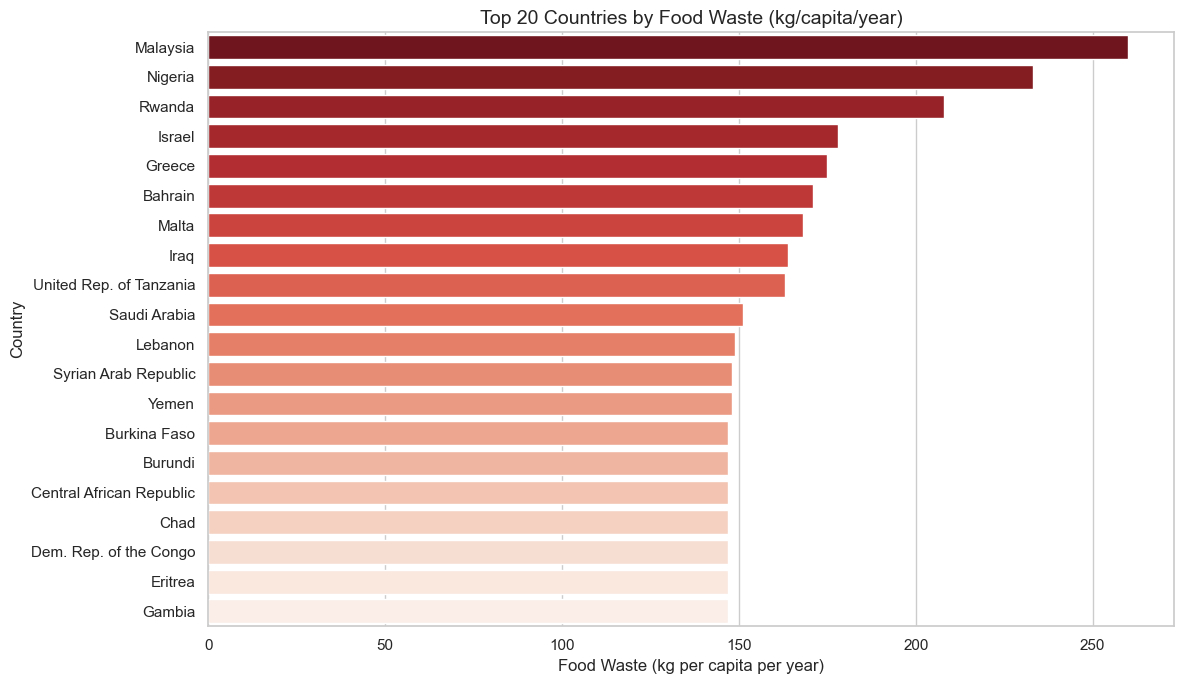

✅ Plot saved!


In [7]:
top20 = df.nlargest(20, 'combined_kg_per_capita')

plt.figure(figsize=(12, 7))
sns.barplot(data=top20, x='combined_kg_per_capita', y='country', palette='Reds_r')
plt.title('Top 20 Countries by Food Waste (kg/capita/year)', fontsize=14)
plt.xlabel('Food Waste (kg per capita per year)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../data/processed/top20_countries.png')
plt.show()
print("✅ Plot saved!")

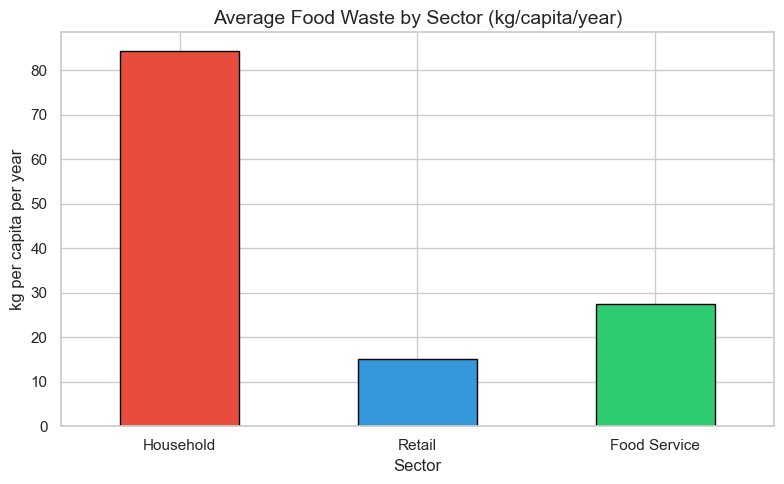

In [9]:
sector_data = df[['household_kg_per_capita',
                   'retail_kg_per_capita',
                   'foodservice_kg_per_capita']].mean()

# Rename for clean labels
sector_data.index = ['Household', 'Retail', 'Food Service']

plt.figure(figsize=(8, 5))
sector_data.plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
plt.title('Average Food Waste by Sector (kg/capita/year)', fontsize=14)
plt.xlabel('Sector')
plt.ylabel('kg per capita per year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/processed/waste_by_sector.png')
plt.show()

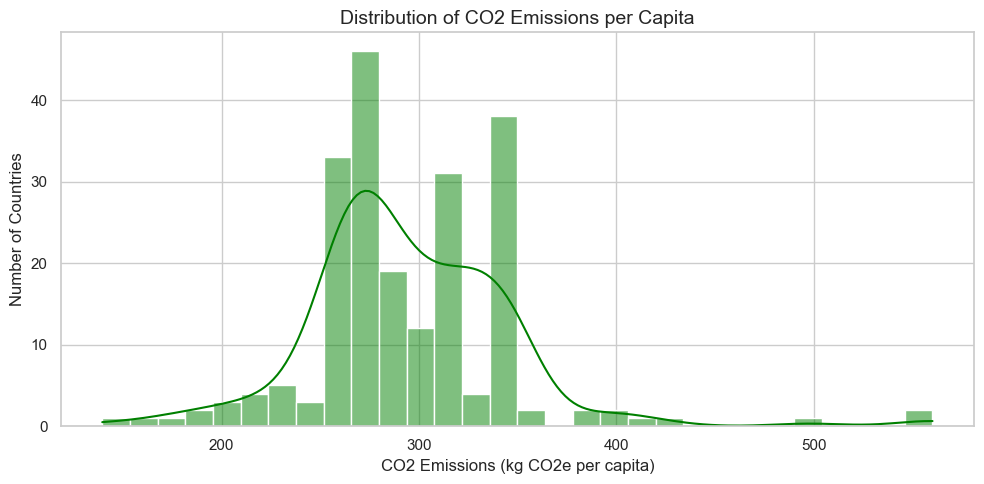

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_co2_per_capita'], bins=30, kde=True, color='green')
plt.title('Distribution of CO2 Emissions per Capita', fontsize=14)
plt.xlabel('CO2 Emissions (kg CO2e per capita)')
plt.ylabel('Number of Countries')
plt.tight_layout()
plt.savefig('../data/processed/co2_distribution.png')
plt.show()

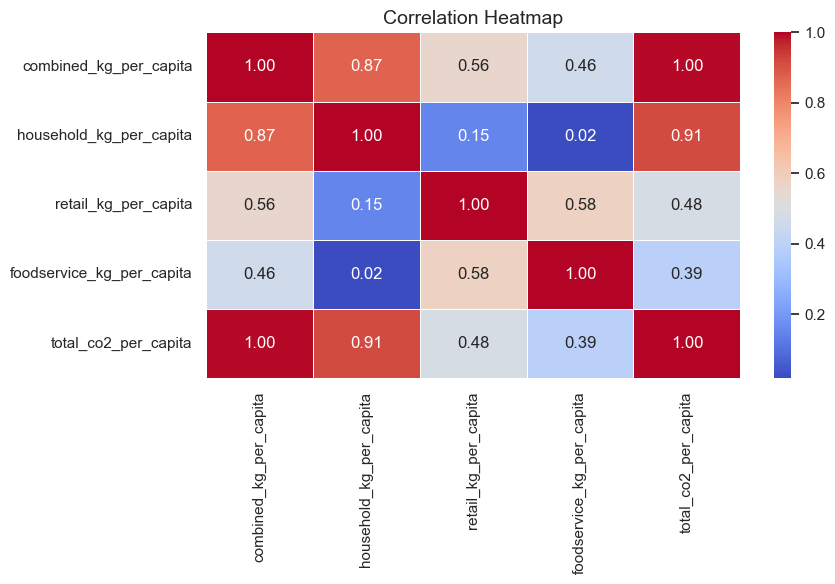

In [11]:
cols = ['combined_kg_per_capita','household_kg_per_capita',
        'retail_kg_per_capita','foodservice_kg_per_capita',
        'total_co2_per_capita']

plt.figure(figsize=(9, 6))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png')
plt.show()

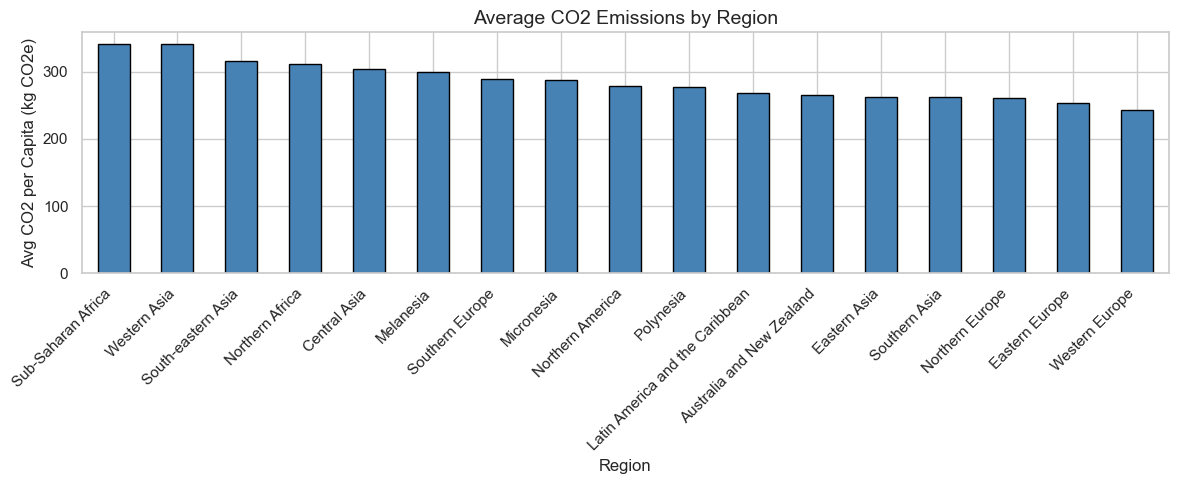

In [12]:
region_co2 = df.groupby('region')['total_co2_per_capita'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
region_co2.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average CO2 Emissions by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Avg CO2 per Capita (kg CO2e)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/co2_by_region.png')
plt.show()

In [13]:
df.to_csv('../data/processed/food_waste_processed.csv', index=False)
print("✅ Processed data saved!")
print(f"Final shape: {df.shape}")
print(f"New columns added: {df.shape[1] - 12}")

✅ Processed data saved!
Final shape: (214, 16)
New columns added: 4
